# What is the relationship between socio-economic factors and crime rates in London?

## Preparation

- [Github link](google.com) *[Optional]*

- Number of words: ***

- Runtime: *** hours (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker (or anything else)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **watermark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.
    - ......

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Import all labs

In [1]:
#import sys
#!{sys.executable} -m pip install xgboost
#!{sys.executable} -m pip install shap

In [2]:
# ============================================================
# CELL 1: Import Libraries
# ============================================================
# Requirements:
# pip install shap xgboost


import warnings
warnings.filterwarnings('ignore')



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce
from scipy import stats
import statsmodels.api as sm
import shap
# Machine Learning
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import randint, uniform
import time
from scipy.stats import randint, uniform

from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import KFold

# Statistics
from statsmodels.stats.outliers_influence import variance_inflation_factor

from statsmodels.tools.tools import add_constant

sns.set_theme(style='whitegrid')
np.random.seed(42)

print('All libraries loaded successfully.')

All libraries loaded successfully.


## Introduction

[[ go back to the top ]](#Table-of-contents)

Crime is a persistent urban issue with important consequences for safety and wellbeing. Previous research shows that crime is closely associated with neighbourhood socio-economic conditions, especially deprivation and broader forms of disadvantage (Lightowlers et al., 2023; Zhou et al., 2023). Social disorganisation theory therefore provides an important framework for explaining why disadvantaged communities may experience higher crime (Shaw & McKay, 1942).

However, deprivation alone may not fully explain crime geography in a large and highly connected city such as London. Routine activity theory and crime pattern theory suggest that crime is also shaped by accessibility, movement, and the spatial concentration of opportunities for offending (Cohen & Felson, 1979; Brantingham & Brantingham, 1993). This study therefore examines whether variation in crime rates across London LSOAs is more strongly associated with socio-economic disadvantage, transport accessibility, or a combination of both.


## Research questions

[[ go back to the top ]](#Table-of-contents)

Against the following background this study seeks to explore the following questions:

- **RQ1:** To what extent can crime rates across London LSOAs be explained by socio-economic and transport-accessibility variables?
- **RQ2:** Which socio-economic dimensions are the strongest predictors of crime, and do they operate through linear or non-linear relationships?
- **RQ3:** Do the identified predictors operate consistently across different crime types (violent vs. property crime), or do distinct socio-economic mechanisms drive different categories of offending?

These three questions form a progressive analytical framework. RQ1 establishes the overall explanatory capacity of neighbourhood-level socio-economic and accessibility variables. RQ2 then focuses on model interpretation, asking which predictors matter most and whether the observed relationships are adequately captured by a linear baseline or whether a more flexible boosted-tree model reveals additional non-linear structure. Finally, RQ3 extends the analysis by disaggregating the outcome into violent and property crime, allowing the study to examine whether different forms of offending reflect different neighbourhood mechanisms.

## Data

[[ go back to the top ]](#Table-of-contents)

The analysis combines Metropolitan Police Service crime data, Census 2021 socio-economic indicators, and TfL Public Transport Accessibility Level (PTAL) data at LSOA level across London. Total crime counts were aggregated for 2021 and 2022, with violent and property crime also constructed for comparative analysis. Crime was standardised as a rate per 1,000 resident population to improve comparability across areas.

Census-based predictors capture age structure, employment, qualifications, migration, language, housing tenure, deprivation, and population density, while PTAL is used as an indicator of neighbourhood accessibility. After merging and cleaning the datasets, the final analytical sample contains 4,988 LSOAs. The main dependent variable is the log-transformed total crime rate in 2021.

| Variable                            | Type         | Description                                                             |Source|
|-------------------------------------|--------------|-------------------------------------------------------------------------|---|
| Crime rate                          | Numeric      | Total crime rate per 1,000 residents, 2021                              |MPS Crime Data   |
| Population                          | Numeric      | Total population of community                                           |Census 2021   |
| Age by broad age bands              | Numeric      | The proportion of the 20-24 age group                                   |Census 2021   |
| Economic activity status            | Numeric      | The proportion of employed people in the community                      | Census 2021  |
| 'Highest level of qualification     | Numeric      | The proportion of degree level 4+ and no degree certification in the community | Census 2021  |
|Households by deprivation dimensions | Numeric      |The proportion of families classified as deprivation                     |Census 2021|
|Migrant Indicator                    | Numeric      |The proportion of address one year ago was outside the UK                |Census 2021|
|Percentage Not born in UK            | Numeric      |The proportion of non-British ethnic groups in the community             |Census 2021|
|Percentage English as the First Language of no one in household| Numeric|-% Households where no one has English as first language|Census 2021|
|Tenure and house situation           |Numeric       |% Social Rented/% Private Rented                                         |Census 2021|
|Public Transport Accessibility Data  |Numeric       |Public transport accessibility index score                               |TfL PTAL|

In [3]:
# ============================================================
# CELL 2: Check the status of the data folder
# ============================================================
import os
from pathlib import Path

# Auto-detect the local data directory so the notebook works on both
# this Windows workspace and the original Jupyter environment.
cwd = Path.cwd().resolve()
candidate_dirs = []
for root in [cwd, *cwd.parents]:
    candidate_dirs.append(root / 'datascience' / 'data')

candidate_dirs.extend([
    Path(r'D:/SDS2025_workspace/fsds/datascience/data'),
    Path('/home/jovyan/work/fsds/datascience/data'),
])

DATA_DIR = None
for candidate in dict.fromkeys(candidate_dirs):
    if candidate.exists():
        DATA_DIR = str(candidate.resolve())
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        'Could not find datascience/data. Expected it under the current '
        'workspace or at D:/SDS2025_workspace/fsds/datascience/data.'
    )

In [4]:
# ============================================================
# CELL 3: Load Crime Data and Identify Crime Categories
# ============================================================
# Source: Metropolitan Police Service LSOA Level Crime (Historical)
# URL: https://data.london.gov.uk/dataset/recorded_crime_summary

crime = pd.read_csv(os.path.join(DATA_DIR, 'MPS LSOA Level Crime (Historical).csv'))

# Identify monthly columns
date_cols = [c for c in crime.columns if str(c).isdigit() and len(str(c)) == 6]
cols_2021 = [c for c in date_cols if str(c).startswith('2021')]
cols_2022 = [c for c in date_cols if str(c).startswith('2022')]

print(f'Total rows in crime dataset: {len(crime):,}')
print(f'2021 monthly columns: {len(cols_2021)} months')
print(f'2022 monthly columns: {len(cols_2022)} months')
print(f'\nCrime categories available:')
print(crime['Major Category'].unique())

# Define crime type groupings for RQ3
# Violent crimes: capture interpersonal harm (social disorganisation perspective)
VIOLENT_CATS = ['VIOLENCE AGAINST THE PERSON', 'ROBBERY']
# Property crimes: capture acquisitive offending (routine activity perspective)
PROPERTY_CATS = ['BURGLARY', 'THEFT', 'VEHICLE OFFENCES']

Total rows in crime dataset: 127,017
2021 monthly columns: 12 months
2022 monthly columns: 12 months

Crime categories available:
['ARSON AND CRIMINAL DAMAGE' 'BURGLARY' 'DRUG OFFENCES'
 'MISCELLANEOUS CRIMES AGAINST SOCIETY' 'POSSESSION OF WEAPONS'
 'PUBLIC ORDER OFFENCES' 'ROBBERY' 'THEFT' 'VEHICLE OFFENCES'
 'VIOLENCE AGAINST THE PERSON']


In [5]:
# ============================================================
# CELL 4: Aggregate Crime Counts by LSOA (Total + Violent + Property)
# ============================================================

# Total crime (primary dependent variable for RQ1 & RQ2)
total_2021 = (crime.groupby('LSOA Code')[cols_2021]
              .sum().sum(axis=1)
              .reset_index(name='Total_Count_2021'))

# Violent crime (for RQ3)
violent_2021 = (crime[crime['Major Category'].isin(VIOLENT_CATS)]
                .groupby('LSOA Code')[cols_2021]
                .sum().sum(axis=1)
                .reset_index(name='Violent_Count_2021'))

# Property crime (for RQ3)
property_2021 = (crime[crime['Major Category'].isin(PROPERTY_CATS)]
                 .groupby('LSOA Code')[cols_2021]
                 .sum().sum(axis=1)
                 .reset_index(name='Property_Count_2021'))

# Merge all counts
df_crime = (total_2021
            .merge(violent_2021,  on='LSOA Code')
            .merge(property_2021, on='LSOA Code'))
df_crime.rename(columns={'LSOA Code': 'LSOA_Code'}, inplace=True)

In [6]:
# ============================================================
# CELL 5: Load Census 2021 Variables
# ============================================================

# --- Population ---
total_res = pd.read_csv(os.path.join(DATA_DIR, 'total residents lsoa.csv'),
                        skiprows=6, on_bad_lines='skip')
total_res = (total_res[['mnemonic', '2021']]
             .rename(columns={'mnemonic': 'LSOA_Code', '2021': 'Population'})
             .dropna())

# --- Age: % aged 20-24 ---
age = pd.read_csv(os.path.join(DATA_DIR, 'Age by broad age bands lsoa .csv'),
                  skiprows=4, on_bad_lines='skip')
age = (age[['mnemonic', 'Aged 20 to 24 years']]
       .rename(columns={'mnemonic': 'LSOA_Code',
                        'Aged 20 to 24 years': 'pct_youth_20_24'})
       .dropna())

# --- employment rate--
econ = pd.read_csv(os.path.join(DATA_DIR, 'Economic activity status lsoa.csv'),
                    skiprows=6, on_bad_lines='skip')
econ = (econ[['mnemonic',
              'Economically active (excluding full-time students):In employment']]
        .rename(columns={
            'mnemonic': 'LSOA_Code',
            'Economically active (excluding full-time students):In employment': 'pct_employed'
        })
        .dropna())
econ['pct_employed'] = pd.to_numeric(econ['pct_employed'], errors='coerce')

# --- Qualifications: % no qualifications ---
qual = pd.read_csv(os.path.join(DATA_DIR, 'Highest level of qualification lsoa.csv'),
                    skiprows=6, on_bad_lines='skip')
qual = (qual[['mnemonic', 'No qualifications', 'Level 4 qualifications or above']]
        .rename(columns={
            'mnemonic': 'LSOA_Code',
            'No qualifications': 'pct_no_qual',
            'Level 4 qualifications or above': 'pct_level4_qual'
        })
        .dropna())

# --- Household Deprivation ---
dep = pd.read_csv(os.path.join(DATA_DIR, 'Households by deprivation dimensions lsoa.csv'),
                  skiprows=6, on_bad_lines='skip')
dep = (dep[['mnemonic', '2021']]
       .rename(columns={'mnemonic': 'LSOA_Code', '2021': 'pct_deprived'})
       .dropna())


# --- Migrant Indicator: % from outside UK ---
migrant = pd.read_csv(os.path.join(DATA_DIR, 'Migrant Indicator lsoa.csv'),
                      skiprows=6, on_bad_lines='skip')
migrant = migrant.iloc[1:].copy()
migrant = (migrant[['mnemonic',
                     'Migrant from outside the UK: Address one year ago was outside the UK']]
           .rename(columns={
               'mnemonic': 'LSOA_Code',
               'Migrant from outside the UK: Address one year ago was outside the UK': 'pct_migrant_outside'
           })
           .dropna())
migrant['pct_migrant_outside'] = pd.to_numeric(migrant['pct_migrant_outside'], errors='coerce')

#Ethnic
# --- Country of Birth: % Not Born in UK [THEME: Ethnic] ---
cb = pd.read_csv(
    os.path.join(DATA_DIR, 'Percentage Not born in UK.csv'),
    skiprows=7,
    on_bad_lines='skip'
)
non_uk_cols = [
    'Europe: EU countries',
    'Europe: Non-EU countries - All other non-EU countries',
    'Africa',
    'Middle East and Asia',
    'The Americas and the Caribbean',
    'Antarctica and Oceania (including Australasia) and Other',
    'British Overseas'
]
for col in non_uk_cols:
    cb[col] = pd.to_numeric(cb[col], errors='coerce')

cb['pct_not_born_uk'] = cb[non_uk_cols].sum(axis=1)
cb = (
    cb[['mnemonic', 'pct_not_born_uk']]
    .rename(columns={'mnemonic': 'LSOA_Code'})
    .dropna(subset=['pct_not_born_uk'])
)

# --- English: % Households where no one has English as first language ---
# [THEME: Ethnic] --- NEWLY ADDED
# Note: this file has no separate mnemonic column — code extracted from label
eng = pd.read_csv(
    os.path.join(DATA_DIR,
                 'Percentage English as the First Language of no one in household.csv'),
    skiprows=6, on_bad_lines='skip'
)
eng.columns = ['lsoa_label', 'pct_no_english']
eng['LSOA_Code'] = eng['lsoa_label'].str.extract(r'(E\d{8})')
eng = (eng[['LSOA_Code', 'pct_no_english']]
       .dropna()
       .assign(pct_no_english=lambda x: pd.to_numeric(x['pct_no_english'],
                                                        errors='coerce')))


# --- Tenure: % Social Rented + % Private Rented ---
tenure = pd.read_csv(os.path.join(DATA_DIR, 'Tenure and house situation lsoa.csv'),  
                     skiprows=6, on_bad_lines='skip')
tenure = (tenure[['mnemonic', 'Social rented', 'Private rented']]
          .rename(columns={
              'mnemonic': 'LSOA_Code',
              'Social rented': 'pct_social_rented',
              'Private rented': 'pct_private_rented'   
          })
          .dropna())

# --- Population Density ---
pop_den = pd.read_csv(os.path.join(DATA_DIR, 'Population density lsoa.csv'),
                      skiprows=6, on_bad_lines='skip')
pop_den = (pop_den[['mnemonic', '2021']]
           .rename(columns={'mnemonic': 'LSOA_Code', '2021': 'pop_density'})
           .dropna())

#  ---  Load Public Transport Accessibility (PTAL) Data
# Source: TfL PTAL 2023, aggregated to LSOA 2021 boundaries

ptai_raw = pd.read_csv(os.path.join(DATA_DIR, 'LSOA_aggregated_PTAL_stats_2023.csv'))

ptai = (ptai_raw[['LSOA21CD', 'mean_AI']]
        .rename(columns={'LSOA21CD': 'LSOA_Code',
                         'mean_AI':  'ptai_score'})
        .copy())

ptai['ptai_score'] = pd.to_numeric(ptai['ptai_score'], errors='coerce')

# Verification
dfs = {
    'total_res'     : (total_res,     ['LSOA_Code', 'Population']),
    'age'           : (age,           ['LSOA_Code', 'pct_youth_20_24']),
    'econ'          : (econ,          ['LSOA_Code', 'pct_employed']),
    'qual'          : (qual,          ['LSOA_Code', 'pct_no_qual', 'pct_level4_qual']),
    'cb'            : (cb,            ['LSOA_Code', 'pct_not_born_uk']),
    'eng'           : (eng,           ['LSOA_Code', 'pct_no_english']),
    'tenure'        : (tenure,        ['LSOA_Code', 'pct_social_rented', 'pct_private_rented']),
    'pop_den'       : (pop_den,       ['LSOA_Code', 'pop_density']),
    'migrant'       : (migrant,       ['LSOA_Code','pct_migrant_outside']),
    'dep'           : (dep,           ['LSOA_Code', 'pct_deprived']),
    'ptai'          : (ptai,          ['LSOA_Code', 'ptai_score']),
}

print('=' * 55)
print(f'{"DataFrame":<16} {"Rows":>6}  {"NaN":>6}  Variables')
print('-' * 55)
for name, (df, cols) in dfs.items():
    nan_count = df[cols[1:]].isna().sum().sum()
    print(f'  {name:<14} {len(df):>6,}  {nan_count:>6}  {cols[1:]}')
print('=' * 55)

DataFrame          Rows     NaN  Variables
-------------------------------------------------------
  total_res       4,988       0  ['Population']
  age             4,988       0  ['pct_youth_20_24']
  econ            4,988       0  ['pct_employed']
  qual            4,988       0  ['pct_no_qual', 'pct_level4_qual']
  cb              4,999       0  ['pct_not_born_uk']
  eng             4,994       0  ['pct_no_english']
  tenure          4,988       0  ['pct_social_rented', 'pct_private_rented']
  pop_den         4,988       0  ['pop_density']
  migrant         4,988       0  ['pct_migrant_outside']
  dep             4,988       0  ['pct_deprived']
  ptai            4,994       0  ['ptai_score']


In [7]:
# ============================================================
# CELL 6: Merge All Datasets
# ============================================================

dfs_to_merge = [
    df_crime,       # main dependent variable crime
    total_res,      # population
    age,            # pct_youth_20_24
    econ,           # pct_employed
    qual,           # pct_no_qual, pct_level4_qual      
    cb,             # pct_not_born_uk            
    eng,            # pct_no_english             
    migrant,        # pct_migrant_outside
    tenure,         # pct_social_rented, pct_private_rented
    pop_den,        # pop_density
    ptai,           # ptai_score
    dep,            # deprivation
]

df = reduce(
    lambda left, right: left.merge(right, on='LSOA_Code', how='inner'),
    dfs_to_merge
)

## Methodology

[[ go back to the top ]](#Table-of-contents)

The analysis proceeds in four steps. First, exploratory analysis is used to examine variable distributions, skewness, and pairwise relationships. Second, LASSO regression is used to select a parsimonious subset of predictors, with the one-standard-error rule applied to favour interpretability over marginal gains in fit (Hastie et al., 2009; Tibshirani, 1996). Third, the retained variables are used to estimate a Linear Regression baseline and an XGBoost model as a more flexible alternative (Chen & Guestrin, 2016). Finally, the selected model is interpreted using permutation importance, SHAP values, and partial dependence plots, and the same framework is extended to violent and property crime (Lundberg & Lee, 2017).

The diagram above illustrates the methodology employed in this study
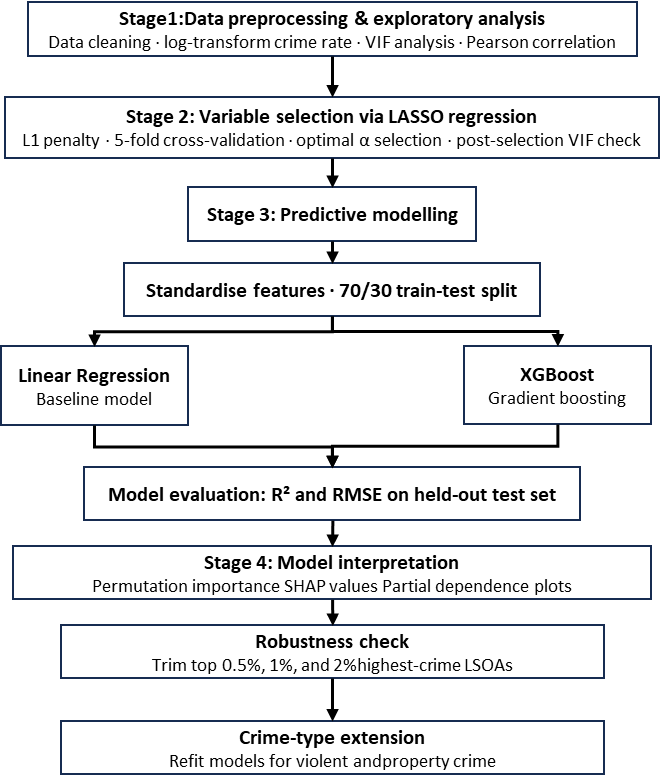

## Results and discussion

[[ go back to the top ]](#Table-of-contents)

## EDA and preparation for modelling

The exploratory analysis shows that the raw crime-rate variables are strongly right-skewed, especially for total and property crime. This suggests that a small number of LSOAs experience exceptionally high recorded crime relative to the rest of London. Log transformation substantially reduces this skewness and produces a more stable outcome for modelling. Several predictors, including PTAL, youth share, migration, and social-rented housing, also show noticeable skewness and are transformed where appropriate. 

In [8]:
# ============================================================
# CELL 7: Calculate Crime Rates and Cleaning
# ============================================================

df = df.dropna()
df['Population'] = pd.to_numeric(df['Population'], errors='coerce')
df = df[df['Population'] > 0]

# Total crime rate (primary dependent variable)
df['Total_Rate_2021']    = df['Total_Count_2021']    / df['Population'] * 1000

# Violent and property crime rates (for RQ3)
df['Violent_Rate_2021']  = df['Violent_Count_2021']  / df['Population'] * 1000
df['Property_Rate_2021'] = df['Property_Count_2021'] / df['Population'] * 1000

# Log transformations (all crime rates are heavily right-skewed)
df['log_total_rate_2021']    = np.log1p(df['Total_Rate_2021'])
df['log_violent_rate_2021']  = np.log1p(df['Violent_Rate_2021'])
df['log_property_rate_2021'] = np.log1p(df['Property_Rate_2021'])

# Population density log transform
df['log_pop_density'] = np.log1p(pd.to_numeric(df['pop_density'], errors='coerce'))

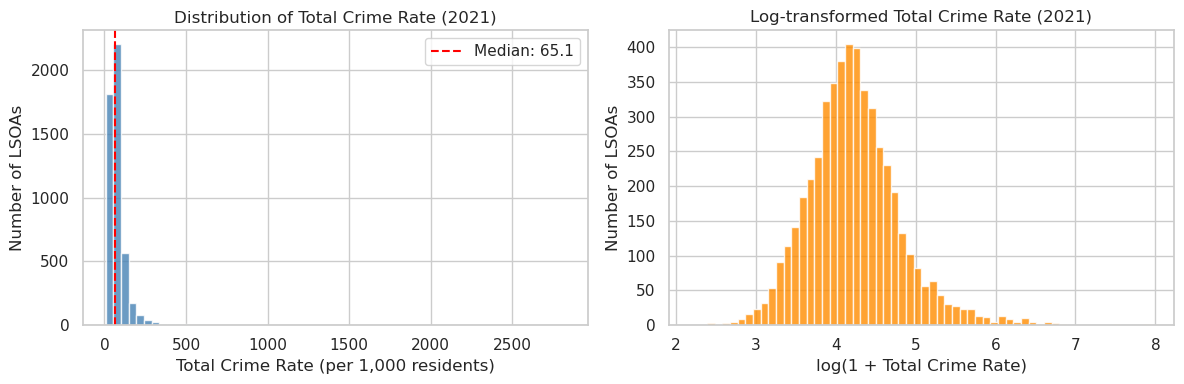

Skewness (raw): 13.24
Skewness (log): 0.84


In [9]:
# ============================================================
# CELL 8: Distribution of Violent Crime Rate
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw distribution
axes[0].hist(df["Total_Rate_2021"], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df["Total_Rate_2021"].median(), color='red',
                linestyle='--', label=f'Median: {df["Total_Rate_2021"].median():.1f}')
axes[0].set_title('Distribution of Total Crime Rate (2021)')
axes[0].set_xlabel('Total Crime Rate (per 1,000 residents)')
axes[0].set_ylabel('Number of LSOAs')
axes[0].legend()

# Log-transformed
axes[1].hist(np.log1p(df["Total_Rate_2021"]), bins=60,
             color='darkorange', edgecolor='white', alpha=0.8)
axes[1].set_title('Log-transformed Total Crime Rate (2021)')
axes[1].set_xlabel('log(1 + Total Crime Rate)')
axes[1].set_ylabel('Number of LSOAs')

plt.tight_layout()
#plt.savefig('fig1_crime_rate_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Skewness (raw): {df["Total_Rate_2021"].skew():.2f}')
print(f'Skewness (log): {np.log1p(df["Total_Rate_2021"]).skew():.2f}')

In [10]:
# ============================================================
# CELL 9: Descriptive analysis of independent variables
# ============================================================
FEATURES = [
    'pct_youth_20_24', 'pct_employed', 'pct_no_qual', 'pct_level4_qual',
    'pct_not_born_uk', 'pct_no_english',
    'pct_migrant_outside', 'pct_social_rented', 'pct_private_rented',
    'pct_deprived', 'ptai_score',
    'log_pop_density'  ,
]
TARGET = 'log_total_rate_2021'
# 7.1 descriptive statistics
# ============================================================
print('=' * 65)
print('7.1 Descriptive Statistics')
print('=' * 65)
desc = df[FEATURES + [TARGET]].describe().T
desc['skewness'] = df[FEATURES + [TARGET]].skew()
desc['kurtosis'] = df[FEATURES + [TARGET]].kurt()
print(desc[['mean', 'std', 'min', 'max', 'skewness', 'kurtosis']].round(3))

7.1 Descriptive Statistics
                       mean     std     min     max  skewness  kurtosis
pct_youth_20_24       6.641   2.896   1.900  37.000     2.643    12.353
pct_employed         59.430   7.492  23.300  88.500     0.187     0.938
pct_no_qual          16.110   6.415   1.500  40.000     0.191    -0.539
pct_level4_qual      46.758  13.816  20.200  87.200     0.395    -0.803
pct_not_born_uk      40.145  13.265   4.500  81.500    -0.107    -0.416
pct_no_english       12.217   6.837   0.000  42.100     0.603    -0.103
pct_migrant_outside   1.722   1.796   0.000  24.200     3.897    23.814
pct_social_rented    22.592  18.625   0.000  92.000     0.899    -0.007
pct_private_rented   29.057  13.668   2.600  86.100     0.479    -0.146
pct_deprived         14.452   5.396   1.500  33.200     0.165    -0.655
ptai_score           13.095  11.219   0.214  98.328     2.447     8.734
log_pop_density       9.019   0.749   4.795  11.658    -1.048     2.621
log_total_rate_2021   4.229   0.585  

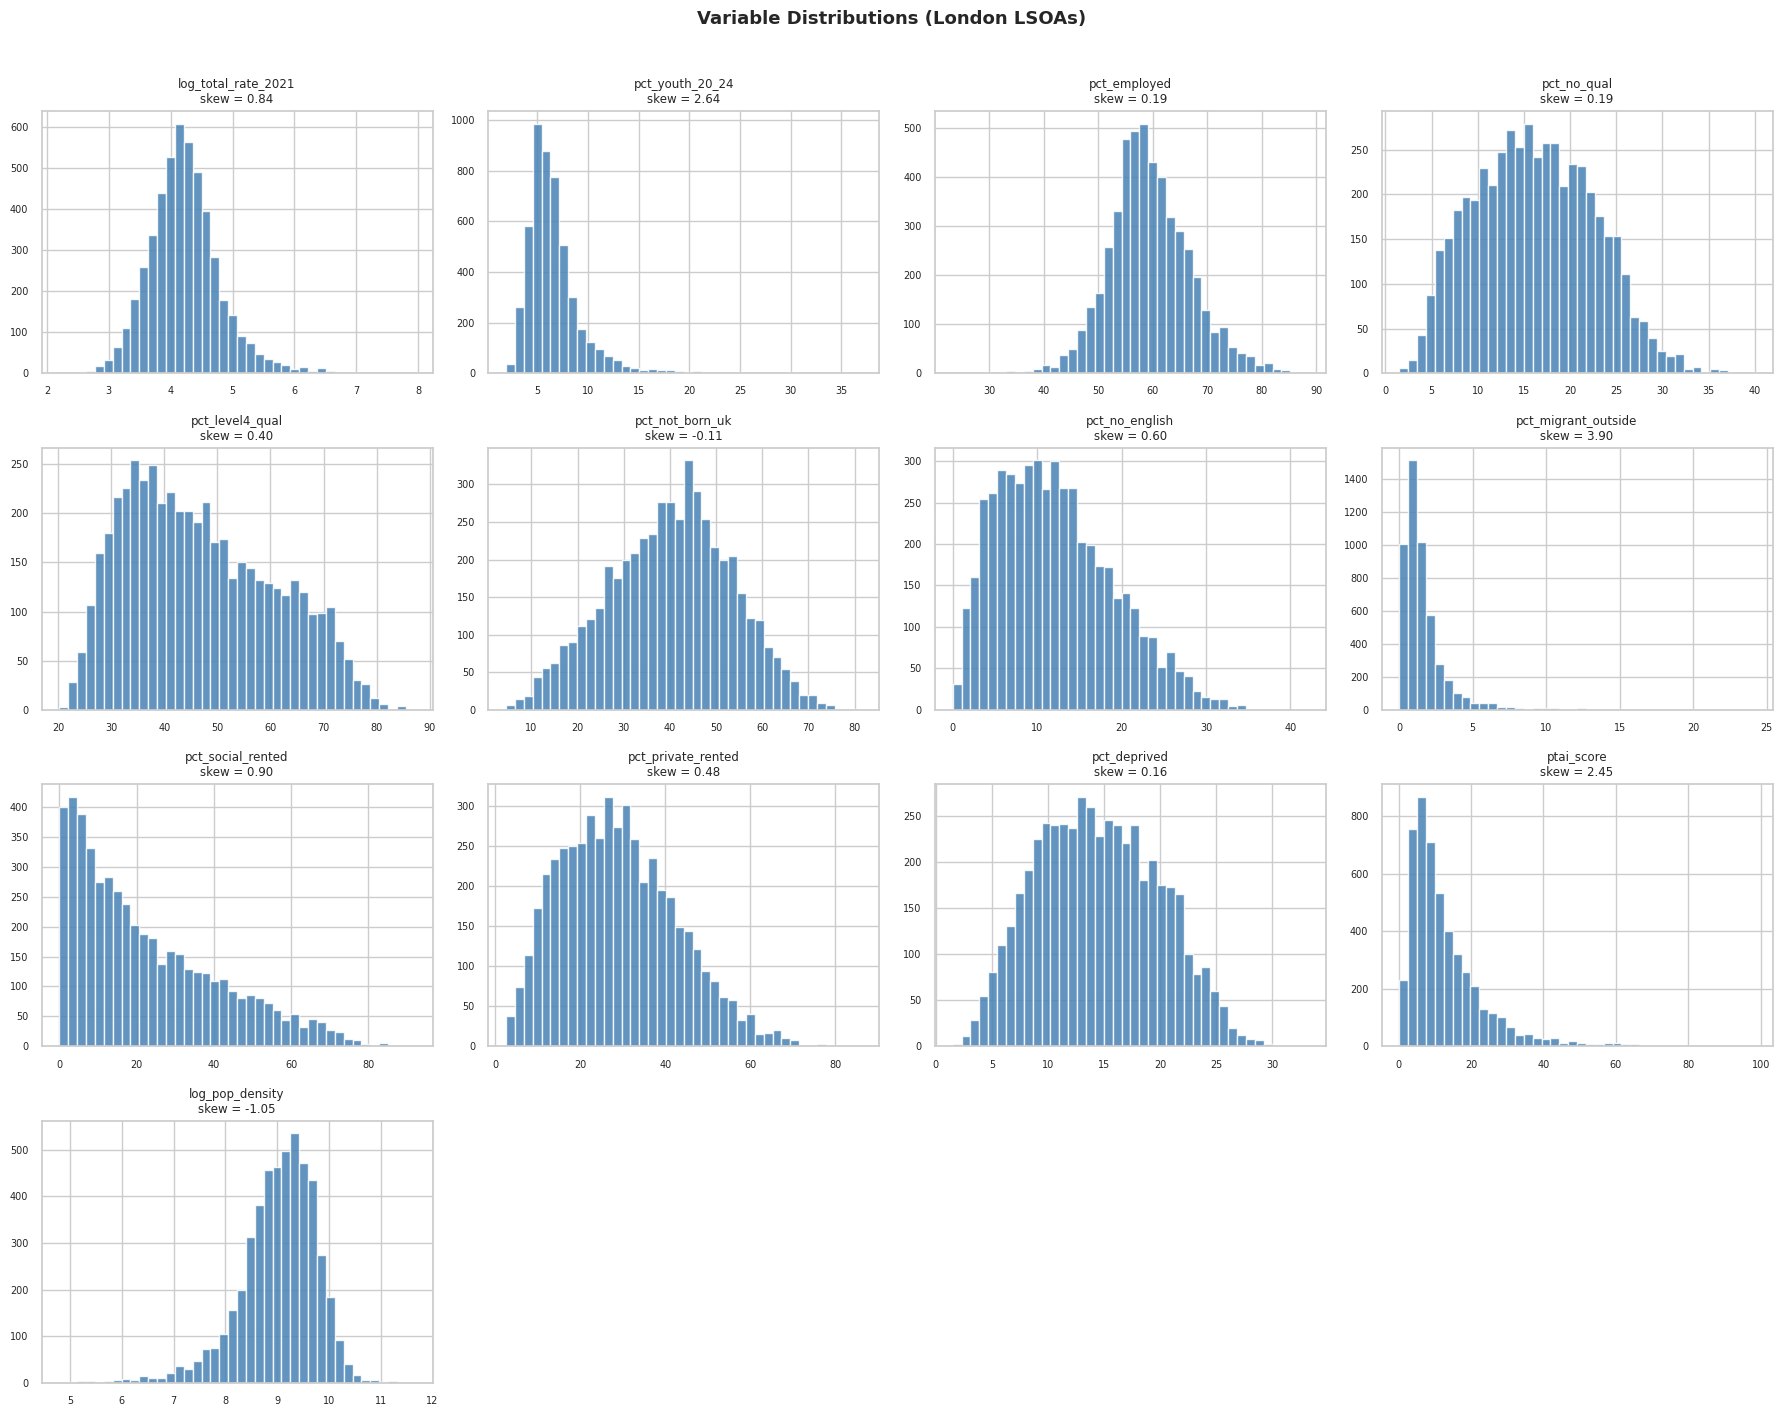

In [11]:
# ============================================================
# CELL 10: Normality test of independent variables
# ============================================================
all_vars = [TARGET] + FEATURES
n_cols = 4
n_rows = -(-len(all_vars) // n_cols)  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(all_vars):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    skew_val = data.skew()
    ax.set_title(f'{col}\nskew = {skew_val:.2f}', fontsize=8.5)
    ax.tick_params(labelsize=7)

for j in range(len(all_vars), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Variable Distributions (London LSOAs)', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

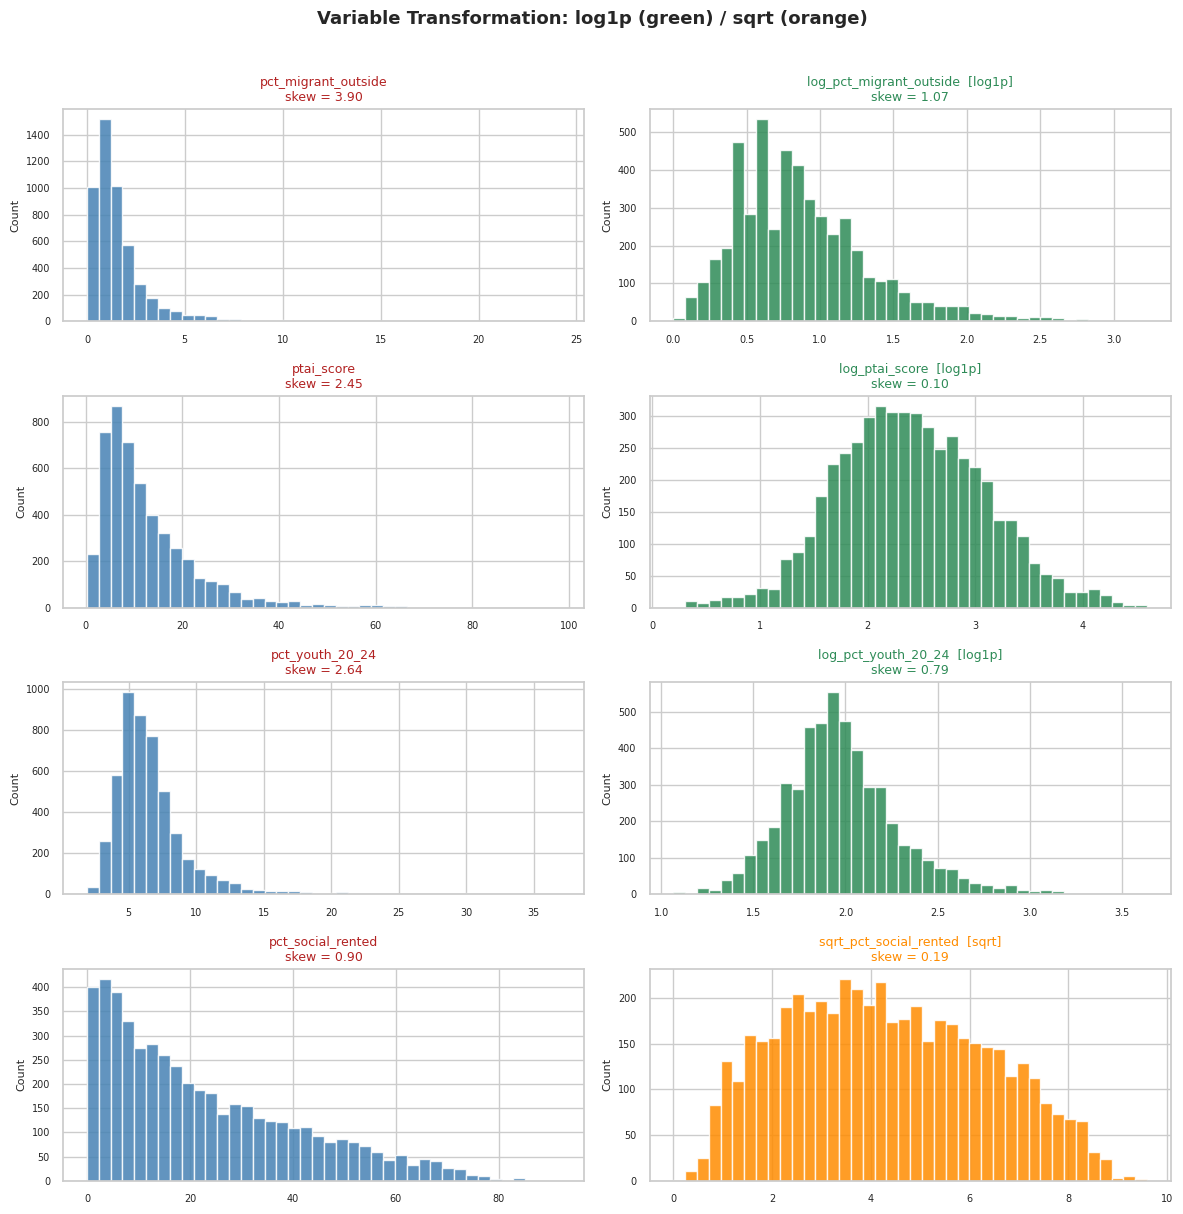

Update FEATURES:
  log_pct_youth_20_24              skew = +0.79  ✓
  pct_employed                     skew = +0.19  ✓
  pct_no_qual                      skew = +0.19  ✓
  pct_level4_qual                  skew = +0.40  ✓
  pct_not_born_uk                  skew = -0.11  ✓
  pct_no_english                   skew = +0.60  ✓
  log_pct_migrant_outside          skew = +1.07  ⚠
  sqrt_pct_social_rented           skew = +0.19  ✓
  pct_private_rented               skew = +0.48  ✓
  pct_deprived                     skew = +0.16  ✓
  log_ptai_score                   skew = +0.10  ✓
  log_pop_density                  skew = -1.05  ⚠


In [12]:
# ============================================================
#  CELL 11: Normalization progress
# ============================================================
LOG_VARS = [
    'pct_migrant_outside',  # skew 3.91
    'ptai_score',           # skew 2.97
    'pct_youth_20_24',      # skew 2.35
]

# 1 < skew < 2 → sqrt transfrom
SQRT_VARS = [
    'pct_social_rented',
]

# pct_social_rented skew=0.95 → < 1，no transfrom

fig, axes = plt.subplots(len(LOG_VARS) + len(SQRT_VARS), 2,
                          figsize=(12, (len(LOG_VARS) + len(SQRT_VARS)) * 3))

row = 0
# --- Log  ---
for var in LOG_VARS:
    new_col = f'log_{var}'
    df[new_col] = np.log1p(df[var])

    axes[row, 0].hist(df[var].dropna(), bins=40,
                      color='steelblue', edgecolor='white', alpha=0.85)
    axes[row, 0].set_title(f'{var}\nskew = {df[var].skew():.2f}',
                            fontsize=9, color='firebrick')
    axes[row, 0].set_ylabel('Count', fontsize=8)

    axes[row, 1].hist(df[new_col].dropna(), bins=40,
                      color='seagreen', edgecolor='white', alpha=0.85)
    axes[row, 1].set_title(f'{new_col}  [log1p]\nskew = {df[new_col].skew():.2f}',
                            fontsize=9, color='seagreen')
    axes[row, 1].set_ylabel('Count', fontsize=8)
    row += 1

# --- Sqrt  ---
for var in SQRT_VARS:
    new_col = f'sqrt_{var}'
    df[new_col] = np.sqrt(df[var])

    axes[row, 0].hist(df[var].dropna(), bins=40,
                      color='steelblue', edgecolor='white', alpha=0.85)
    axes[row, 0].set_title(f'{var}\nskew = {df[var].skew():.2f}',
                            fontsize=9, color='firebrick')
    axes[row, 0].set_ylabel('Count', fontsize=8)

    axes[row, 1].hist(df[new_col].dropna(), bins=40,
                      color='darkorange', edgecolor='white', alpha=0.85)
    axes[row, 1].set_title(f'{new_col}  [sqrt]\nskew = {df[new_col].skew():.2f}',
                            fontsize=9, color='darkorange')
    axes[row, 1].set_ylabel('Count', fontsize=8)
    row += 1

for ax in axes.flatten():
    ax.tick_params(labelsize=7)

plt.suptitle('Variable Transformation: log1p (green) / sqrt (orange)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# --- Update FEATURES List ---
FEATURES = []
for v in ['pct_youth_20_24', 'pct_employed', 'pct_no_qual', 'pct_level4_qual',
        'pct_not_born_uk', 'pct_no_english',
          'pct_migrant_outside', 'pct_social_rented', 'pct_private_rented',
          'pct_deprived', 'ptai_score','log_pop_density']:
    if v in LOG_VARS:
        FEATURES.append(f'log_{v}')
    elif v in SQRT_VARS:
        FEATURES.append(f'sqrt_{v}')
    else:
        FEATURES.append(v)   

print('Update FEATURES:')
for f in FEATURES:
    skew = df[f].skew()
    flag = '  ⚠' if abs(skew) > 1 else '  ✓'
    print(f'  {f:<32} skew = {skew:+.2f}{flag}')


 Correlation heatmap


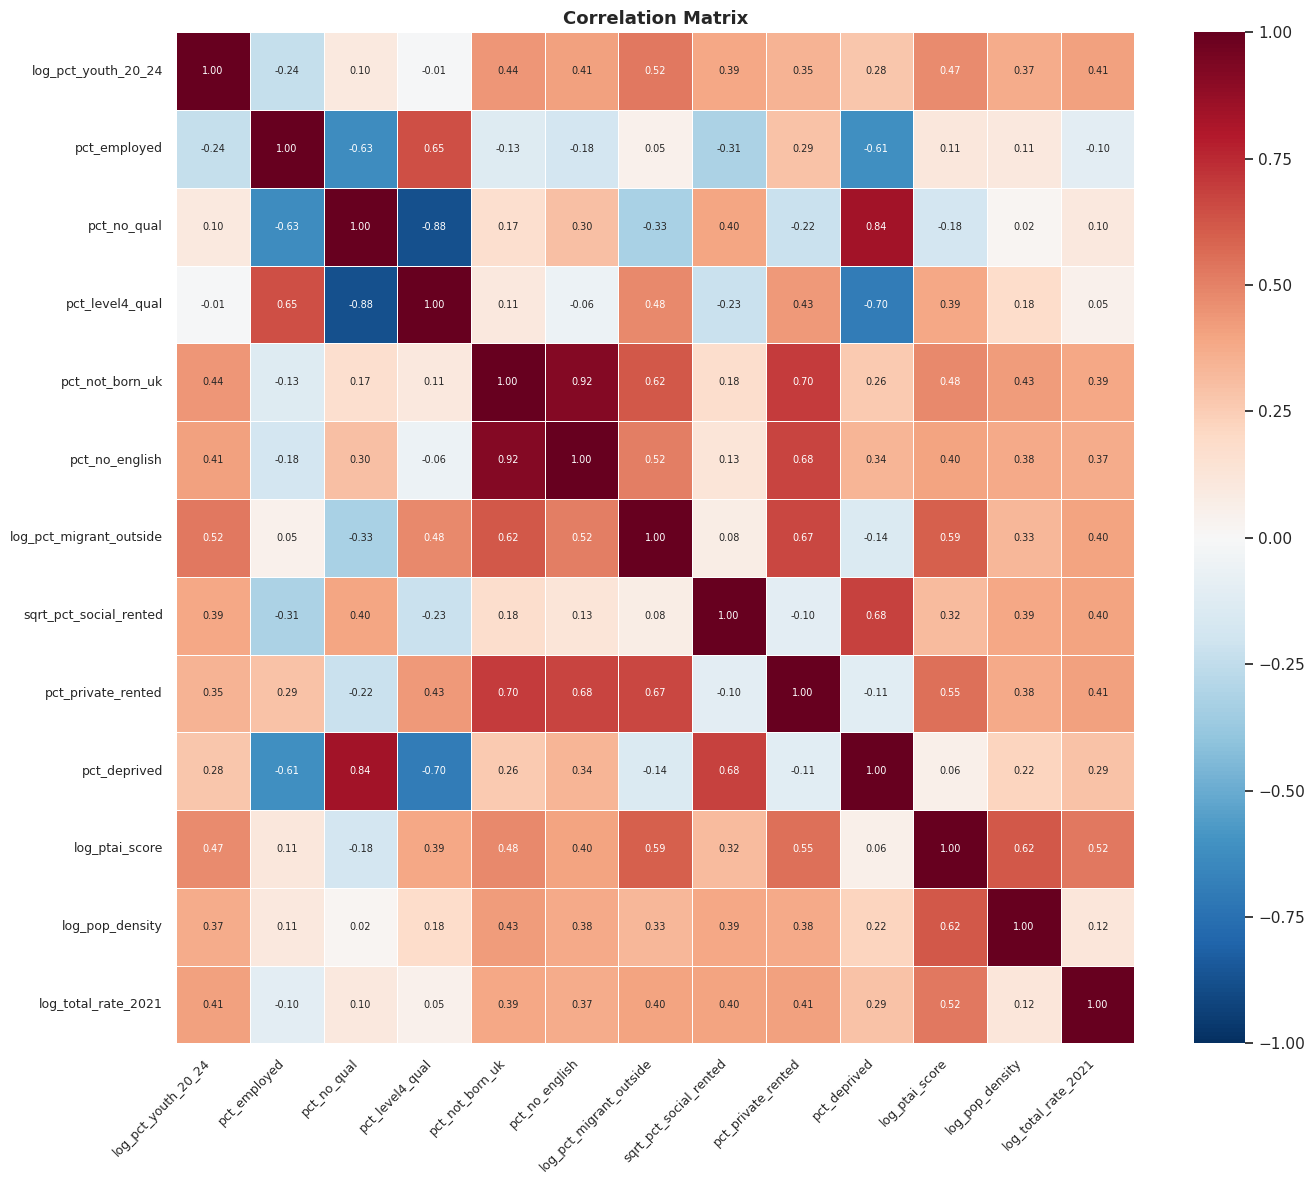

In [13]:
# ============================================================
#  CELL 12: Correlation Heatmap
# ============================================================
print('\n Correlation heatmap')
corr_matrix = df[FEATURES + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 7}
)

ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

## 
The correlation matrix provides an initial overview of relationships between variables. Several factors, including deprivation, housing tenure, and accessibility, show moderate positive associations with crime rates.

However, strong correlations are also observed among independent variables, indicating potential multicollinearity. Therefore, these patterns are treated as exploratory, and formal variable selection is conducted using regression-based methods in subsequent analysis.

## VIF Analysis

In [14]:
# ============================================================
# CELL 13: VIF Analysis — Detect Multicollinearity
# ============================================================
# Features with VIF > 10 indicate severe multicollinearity
# and should be considered for removal

X_vif = df[FEATURES].dropna()

X_vif = add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data = vif_data[vif_data['Feature'] != 'const']

vif_data = vif_data.sort_values('VIF', ascending=False)

vif_data['Flag'] = vif_data['VIF'].apply(
    lambda x: 'High' if x > 10 else 'OK'
)

print(vif_data.round(2))


                    Feature   VIF Flag
3               pct_no_qual  9.39   OK
6            pct_no_english  9.09   OK
4           pct_level4_qual  8.77   OK
5           pct_not_born_uk  8.77   OK
10             pct_deprived  7.93   OK
9        pct_private_rented  4.42   OK
7   log_pct_migrant_outside  3.61   OK
8    sqrt_pct_social_rented  3.59   OK
2              pct_employed  2.71   OK
11           log_ptai_score  2.63   OK
12          log_pop_density  1.96   OK
1       log_pct_youth_20_24  1.96   OK


The VIF results indicate that, although the correlation heatmap reveals a potential risk of multicollinearity among the variables, the multicollinearity of all variables remains within acceptable limits (VIF < 10). We therefore retained all variables for the standardisation process and used the Lasso method to further reduce the set of variables.

## Lasso analysis

In [15]:
# ============================================================
# CELL 14: Train/Test Split → standardization（On trainning datasite）
# ============================================================


y_col = 'log_total_rate_2021'

X_raw = df[FEATURES].values
y_raw = df[y_col].values


indices = np.arange(len(X_raw))
idx_train, idx_test, y_train_raw, y_test_raw = train_test_split(
    indices, y_raw, test_size=0.3, random_state=42
)
X_train_raw = X_raw[idx_train]
X_test_raw  = X_raw[idx_test]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

X_scaled_df = pd.DataFrame(X_train_scaled, columns=FEATURES)
df_model = X_scaled_df.copy()
df_model[y_col] = y_train_raw

best α : 0.001024
 R²   : 0.5660
 RMSE : 0.3842

  Feature                              Coef  Status
-------------------------------------------------------
  log_pop_density                   -0.3016  ✓ retained
  log_ptai_score                     0.2732  ✓ retained
  pct_private_rented                 0.2272  ✓ retained
  sqrt_pct_social_rented             0.2068  ✓ retained
  pct_deprived                       0.1002  ✓ retained
  log_pct_migrant_outside            0.0285  ✓ retained
  log_pct_youth_20_24                0.0272  ✓ retained
  pct_level4_qual                   -0.0252  ✓ retained
  pct_employed                       0.0227  ✓ retained
  pct_no_english                    -0.0182  ✓ retained
  pct_no_qual                        0.0000  ✗ eliminated
  pct_not_born_uk                    0.0000  ✗ eliminated

✓ retained variables (10): ['log_pop_density', 'log_ptai_score', 'pct_private_rented', 'sqrt_pct_social_rented', 'pct_deprived', 'log_pct_migrant_outside', 'log_pct_y

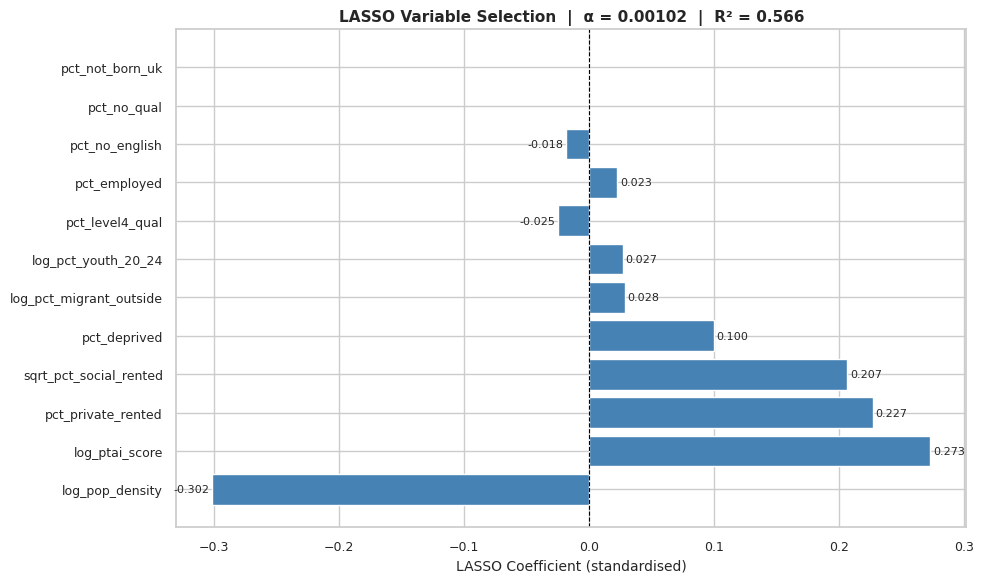

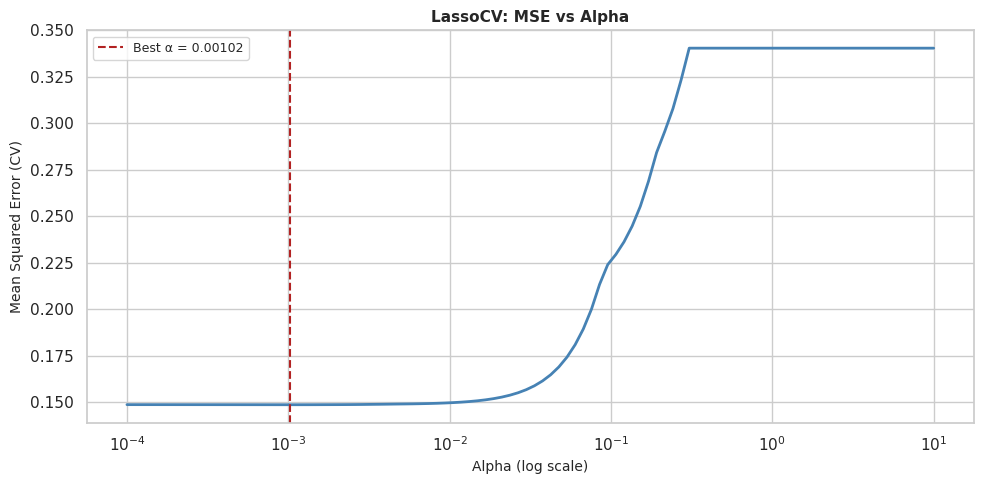

In [16]:
# ============================================================
# CELL 15: LASSO Regression — Variable Selection
# ============================================================

X = df_model[FEATURES].values
y = df_model[y_col].values

# --- 8.1 LassoCV 
kf = KFold(n_splits=5, shuffle=True, random_state=42)

lasso_cv = LassoCV(
    alphas=np.logspace(-4, 1, 100),  # search range 0.0001 ~ 10
    cv=kf,
    max_iter=10000,
    random_state=42
)
lasso_cv.fit(X, y)

best_alpha = lasso_cv.alpha_
print(f'best α : {best_alpha:.6f}')

lasso_final = Lasso(alpha=best_alpha, max_iter=10000)
lasso_final.fit(X, y)

y_pred = lasso_final.predict(X)
r2  = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

print(f' R²   : {r2:.4f}')
print(f' RMSE : {rmse:.4f}')

# --- 8.3 Coefficient Table---
coef_df = pd.DataFrame({
    'Feature'    : FEATURES,
    'Coefficient': lasso_final.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

coef_df['Status'] = coef_df['Coefficient'].apply(
    lambda x: '✓ retained' if x != 0 else '✗ eliminated'
)

print('\n' + '=' * 55)
print(f'  {"Feature":<30} {"Coef":>10}  Status')
print('-' * 55)
for _, row in coef_df.iterrows():
    marker = '  ' if row['Coefficient'] != 0 else '  (zeroed)'
    print(f'  {row["Feature"]:<30} {row["Coefficient"]:>10.4f}  {row["Status"]}')
print('=' * 55)

retained = coef_df[coef_df['Coefficient'] != 0]['Feature'].tolist()
eliminated = coef_df[coef_df['Coefficient'] == 0]['Feature'].tolist()
print(f'\n✓ retained variables ({len(retained)}): {retained}')
print(f'✗ eliminated variables ({len(eliminated)}): {eliminated}')

# --- 8.4 Coefficient visualization ---
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['steelblue' if c != 0 else 'lightgrey'
          for c in coef_df['Coefficient']]
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'],
               color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('LASSO Coefficient (standardised)', fontsize=10)
ax.set_title(f'LASSO Variable Selection  |  α = {best_alpha:.5f}'
             f'  |  R² = {r2:.3f}', fontsize=11, fontweight='bold')
ax.tick_params(labelsize=9)


for bar, val in zip(bars, coef_df['Coefficient']):
    if val != 0:
        ax.text(val + (0.002 if val >= 0 else -0.002),
                bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center',
                ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

# --- 8.5 Alpha value---
fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(lasso_cv.alphas_, lasso_cv.mse_path_.mean(axis=1),
            color='steelblue', linewidth=2)
ax.axvline(best_alpha, color='firebrick', linestyle='--',
           label=f'Best α = {best_alpha:.5f}')
ax.set_xlabel('Alpha (log scale)', fontsize=10)
ax.set_ylabel('Mean Squared Error (CV)', fontsize=10)
ax.set_title('LassoCV: MSE vs Alpha', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Selecting α by the One-Standard-Error Rule

LASSO is used to identify a more interpretable subset of predictors. While `LassoCV` identifies the α that minimises cross-validated error, this often retains variables with negligible contributions. We apply the one-standard-error rule (Hastie et al., 2009): select the largest α whose CV error remains within one standard error of the minimum. This yields a more parsimonious, interpretable model at minimal predictive cost.

This methord reduces the candidate set to seven main predictors: PTAL, population density, private-rented housing, social-rented housing, deprivation, youth share, and recent migration from outside the UK.
Which supports the use of a smaller set of variables that still capture the main socio-economic and accessibility structure of London neighbourhoods.

In [17]:
# ============================================================
# CELL 16: LASSO α Selection via One-Standard-Error Rule
# ============================================================
# Reference: Hastie, Tibshirani & Friedman (2009), The Elements of Statistical Learning

# Retrieve CV MSE mean and std across folds from LassoCV
mse_mean = lasso_cv.mse_path_.mean(axis=1)
mse_std  = lasso_cv.mse_path_.std(axis=1)
min_idx  = mse_mean.argmin()

# 1-SE threshold: minimum CV MSE + 1 standard error
threshold = mse_mean[min_idx] + mse_std[min_idx]

# The largest α whose CV MSE stays below this threshold
candidates = np.where(mse_mean <= threshold)[0]
alpha_1se  = lasso_cv.alphas_[candidates].max()

print(f'CV-optimal α     : {best_alpha:.5f}')
print(f'1-SE α (chosen)  : {alpha_1se:.5f}')
print(f'  Min CV-MSE     : {mse_mean[min_idx]:.4f}')
print(f'  1-SE threshold : {threshold:.4f}')

# Fit LASSO at the 1-SE α
lasso_1se = Lasso(alpha=alpha_1se, max_iter=10000).fit(X, y)

coef_1se = pd.DataFrame({
    'Feature'    : FEATURES,
    'Coefficient': lasso_1se.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
coef_1se['Status'] = coef_1se['Coefficient'].apply(
    lambda x: '✓ retained' if x != 0 else '✗ eliminated')

print('\n' + '=' * 55)
print(f'  {"Feature":<30} {"Coef":>10}  Status')
print('-' * 55)
for _, row in coef_1se.iterrows():
    print(f'  {row["Feature"]:<30} {row["Coefficient"]:>10.4f}  {row["Status"]}')
print('=' * 55)

retained_final   = coef_1se[coef_1se['Coefficient'] != 0]['Feature'].tolist()
eliminated_final = coef_1se[coef_1se['Coefficient'] == 0]['Feature'].tolist()
print(f'\n✓ Retained ({len(retained_final)}): {retained_final}')
print(f'✗ Eliminated ({len(eliminated_final)}): {eliminated_final}')

CV-optimal α     : 0.00102
1-SE α (chosen)  : 0.02364
  Min CV-MSE     : 0.1488
  1-SE threshold : 0.1543

  Feature                              Coef  Status
-------------------------------------------------------
  log_ptai_score                     0.2312  ✓ retained
  log_pop_density                   -0.2246  ✓ retained
  pct_private_rented                 0.1915  ✓ retained
  sqrt_pct_social_rented             0.1830  ✓ retained
  pct_deprived                       0.0705  ✓ retained
  log_pct_youth_20_24                0.0246  ✓ retained
  log_pct_migrant_outside            0.0084  ✓ retained
  pct_employed                      -0.0000  ✗ eliminated
  pct_level4_qual                   -0.0000  ✗ eliminated
  pct_no_qual                        0.0000  ✗ eliminated
  pct_not_born_uk                    0.0000  ✗ eliminated
  pct_no_english                     0.0000  ✗ eliminated

✓ Retained (7): ['log_ptai_score', 'log_pop_density', 'pct_private_rented', 'sqrt_pct_social_rented', 

In [18]:
# ============================================================
# CELL 17: Vif check after LASSO selection
# ============================================================

FEATURES_FINAL = retained_final   


X = df[FEATURES_FINAL].copy()


X = sm.add_constant(X)


vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]


vif_df = vif_df.sort_values(by="VIF", ascending=False)

print("\nVIF result：")
print(vif_df.round(2))


VIF result：
                  Variable     VIF
0                    const  206.59
4   sqrt_pct_social_rented    2.69
7  log_pct_migrant_outside    2.63
1           log_ptai_score    2.52
3       pct_private_rented    2.35
5             pct_deprived    2.23
2          log_pop_density    1.81
6      log_pct_youth_20_24    1.77


## Comparative Analysis of XGboots and Linear Regression

The retained variables are then used in two predictive models. Linear Regression provides an interpretable baseline, while XGBoost is used to test whether more flexible functional forms improve performance. The two models perform similarly, with Linear Regression achieving a test R² of 0.543 and XGBoost improving this slightly to 0.558. This indicates that the main predictive signal is relatively stable and not dependent on highly complex model forms.

In [19]:
# ============================================================
# CELL 18: Final Data Preparation for Modelling (FEATURES_FINAL)
# ============================================================

df_final = df[FEATURES_FINAL + ['log_total_rate_2021',
                                'log_violent_rate_2021',
                                'log_property_rate_2021']].dropna().copy()
# Alias for use in RQ3 crime-type analysis (Cell 31)
df_final_ct = df_final.copy()

X_final = df_final[FEATURES_FINAL].values
y_2021  = df_final['log_total_rate_2021'].values

X_train = X_final[idx_train]
X_test  = X_final[idx_test]
y_train = y_2021[idx_train]
y_test  = y_2021[idx_test]

model_scaler   = StandardScaler()
X_train_scaled = model_scaler.fit_transform(X_train)
X_test_scaled  = model_scaler.transform(X_test)

print(f'Training set  : {X_train.shape[0]:,} LSOAs')
print(f'Test set      : {X_test.shape[0]:,} LSOAs')
print(f'Features      : {FEATURES_FINAL}')

Training set  : 3,491 LSOAs
Test set      : 1,497 LSOAs
Features      : ['log_ptai_score', 'log_pop_density', 'pct_private_rented', 'sqrt_pct_social_rented', 'pct_deprived', 'log_pct_youth_20_24', 'log_pct_migrant_outside']


In [20]:
# ============================================================
# CELL 19: Baseline — Linear Regression
# ============================================================
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_train_r2   = r2_score(y_train, lr.predict(X_train_scaled))
lr_test_r2    = r2_score(y_test,  lr.predict(X_test_scaled))
lr_test_rmse  = np.sqrt(mean_squared_error(y_test, lr.predict(X_test_scaled)))

print('=== Linear Regression (Baseline) ===')
print(f'  Train R²:  {lr_train_r2:.3f}')
print(f'  Test  R²:  {lr_test_r2:.3f}')
print(f'  Test RMSE: {lr_test_rmse:.3f}')

=== Linear Regression (Baseline) ===
  Train R²:  0.564
  Test  R²:  0.543
  Test RMSE: 0.399


In [21]:
# ============================================================
# CELL 20: XGBoost — Hyperparameter Tuning
# ============================================================
param_dist_xgb = {
    'n_estimators'      : randint(100, 500),
    'max_depth'         : randint(3, 10),
    'learning_rate'     : uniform(0.01, 0.3),
    'subsample'         : uniform(0.6, 0.4),      # 0.6 ~ 1.0
    'colsample_bytree'  : uniform(0.5, 0.5),      # 0.5 ~ 1.0
    'min_child_weight'  : randint(1, 10),
    'reg_alpha'         : uniform(0, 1),           
    'reg_lambda'        : uniform(0, 2),          
}

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        verbosity=0,
        n_jobs=-1
    ),
    param_distributions=param_dist_xgb,
    n_iter=80,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

start = time.time()
xgb_search.fit(X_train_scaled, y_train)
print(f'finish in time {time.time()-start:.1f}s')
print(f'best parameter: {xgb_search.best_params_}')
print(f'best CV R²: {xgb_search.best_score_:.4f}')

best_xgb = xgb_search.best_estimator_

xgb_train_r2 = r2_score(y_train, best_xgb.predict(X_train_scaled))
xgb_test_r2  = r2_score(y_test,  best_xgb.predict(X_test_scaled))
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, best_xgb.predict(X_test_scaled)))
xgb_cv_r2    = xgb_search.best_score_

print(f'\n=== XGBoost (Tuned) ===')
print(f' Train R² : {xgb_train_r2:.3f}')
print(f' CV R²    : {xgb_cv_r2:.3f}')
print(f' Test R²  : {xgb_test_r2:.3f}')
print(f' Test RMSE: {xgb_test_rmse:.3f}')

finish in time 12.6s
best parameter: {'colsample_bytree': np.float64(0.7954166302845054), 'learning_rate': np.float64(0.01915007498171483), 'max_depth': 6, 'min_child_weight': 6, 'n_estimators': 370, 'reg_alpha': np.float64(0.3601906414112629), 'reg_lambda': np.float64(0.25412102530376957), 'subsample': np.float64(0.8088973040219217)}
best CV R²: 0.5877

=== XGBoost (Tuned) ===
 Train R² : 0.801
 CV R²    : 0.588
 Test R²  : 0.558
 Test RMSE: 0.392


In [22]:
# ============================================================
# CELL 21: Performance Comparison of the Three Models
# ============================================================
# --- XGBoost ---
best_xgb = xgb_search.best_estimator_
xgb_train_r2 = r2_score(y_train, best_xgb.predict(X_train_scaled))
xgb_test_r2  = r2_score(y_test,  best_xgb.predict(X_test_scaled))
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, best_xgb.predict(X_test_scaled)))
xgb_cv_r2    = xgb_search.best_score_

# --- moodel comparation ---
print('=== Linear Regression ===')
print(f' Train R² : {lr_train_r2:.3f}')
print(f' CV R²    : N/A')
print(f' Test R²  : {lr_test_r2:.3f}')
print(f' Test RMSE: {lr_test_rmse:.3f}')

print('\n=== XGBoost (Tuned) ===')
print(f' Train R² : {xgb_train_r2:.3f}')
print(f' CV R²    : {xgb_cv_r2:.3f}')
print(f' Test R²  : {xgb_test_r2:.3f}')
print(f' Test RMSE: {xgb_test_rmse:.3f}')

# --- comparation table ---
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'XGBoost'],
    'Train R²': [
        round(lr_train_r2, 3),
        round(xgb_train_r2, 3)
    ],
    'CV R²': [
        'N/A',
        round(xgb_cv_r2, 3)
    ],
    'Test R²': [
        round(lr_test_r2, 3),
        round(xgb_test_r2, 3)
    ],
    'Test RMSE': [
        round(lr_test_rmse, 3),
        round(xgb_test_rmse, 3)
    ]
})

print('\n=== Model Comparison ===')
print(comparison.to_string(index=False))

=== Linear Regression ===
 Train R² : 0.564
 CV R²    : N/A
 Test R²  : 0.543
 Test RMSE: 0.399

=== XGBoost (Tuned) ===
 Train R² : 0.801
 CV R²    : 0.588
 Test R²  : 0.558
 Test RMSE: 0.392

=== Model Comparison ===
            Model  Train R²  CV R²  Test R²  Test RMSE
Linear Regression     0.564    N/A    0.543      0.399
          XGBoost     0.801  0.588    0.558      0.392


## Answer for RQ1
For RQ1, the results show that neighbourhood socio-economic and accessibility variables explain a meaningful but incomplete share of crime variation across London. The limited improvement from XGBoost over Linear Regression suggests that much of the structure can already be captured by a relatively simple model. At the same time, a substantial share of variation remains unexplained, implying that crime geography is also shaped by additional influences not fully represented here, such as spatial clustering, land-use intensity, policing context, or other aspects of urban centrality.

Text(0.5, 1.02, 'Predicted vs Actual: log(Total Crime Rate) — 2021 Test Set')

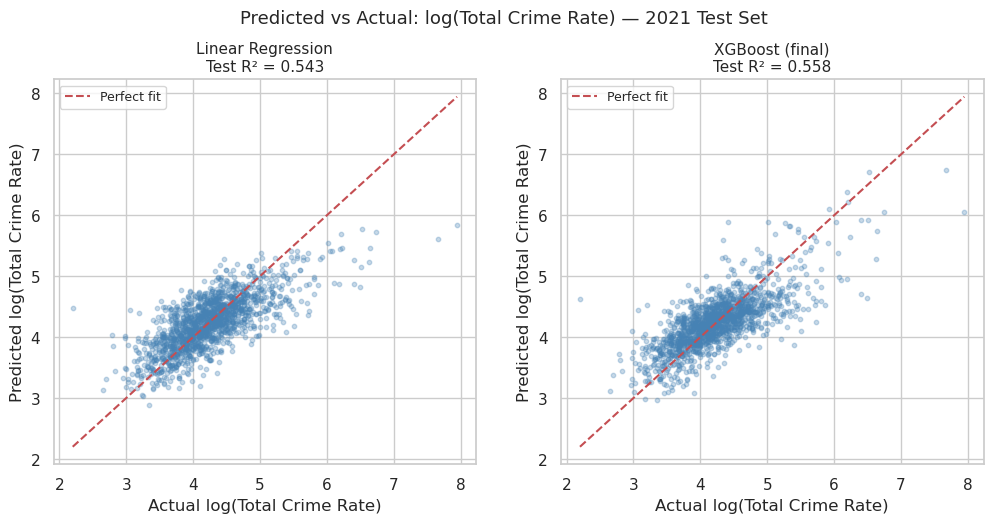

In [23]:
# ============================================================
# CELL 22: Predicted vs Actual Plot
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, name in zip(axes,
                            [lr, best_xgb],          
                            ['Linear Regression', 'XGBoost (final)']): 
    y_pred = model.predict(X_test_scaled)
    r2     = r2_score(y_test, y_pred)

    ax.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
    lims = [min(y_test.min(), y_pred.min()),
            max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_title(f'{name}\nTest R² = {r2:.3f}', fontsize=11)
    ax.set_xlabel('Actual log(Total Crime Rate)')     
    ax.set_ylabel('Predicted log(Total Crime Rate)')  
    ax.legend(fontsize=9)

plt.suptitle('Predicted vs Actual: log(Total Crime Rate) — 2021 Test Set',   
             fontsize=13, y=1.02)

**

### Global Feature Importance
XGBoost is retained as the final interpretation model because it achieves the highest held-out test performance while still generalising reasonably well. Permutation importance and SHAP values both indicate that PTAL is the strongest predictor in the final model. The next most important variables are social-rented housing, population density, private-rented housing, and deprivation, while youth share and migration contribute more weakly once broader neighbourhood structure is taken into account.

Permutation Importance (XGBoost):
                Feature  Importance    Std
         log_ptai_score      0.4856 0.0305
        log_pop_density      0.3359 0.0202
     pct_private_rented      0.1642 0.0096
 sqrt_pct_social_rented      0.1601 0.0108
           pct_deprived      0.0846 0.0066
log_pct_migrant_outside      0.0105 0.0028
    log_pct_youth_20_24      0.0095 0.0028


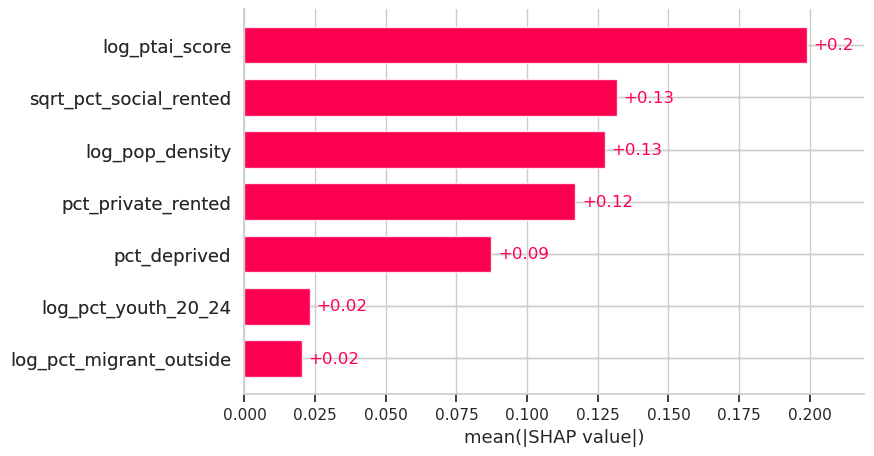

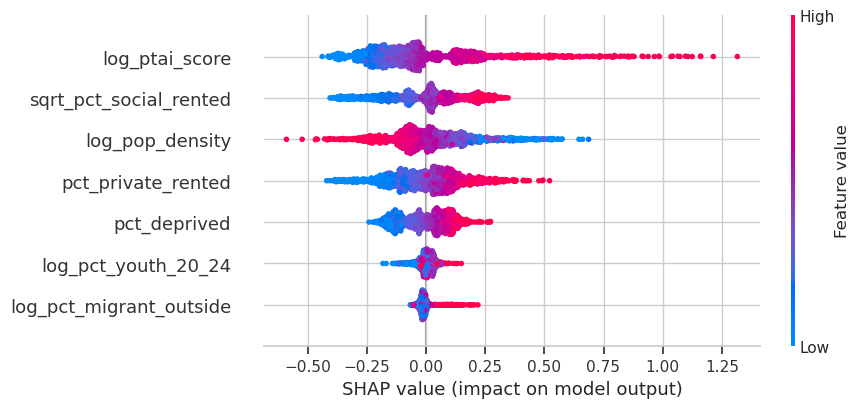

In [24]:
# ============================================================
# CELL 23: Re-run Permutation Importance & SHAP on XGBoost
# ============================================================
# We switch from RF to XGBoost as the final interpretation model
# (see train-test gap discussion above).

# --- Permutation importance on XGBoost ---
perm_xgb = permutation_importance(
    best_xgb, X_test_scaled, y_test,
    n_repeats=10, random_state=42, scoring='r2'
)
perm_df = pd.DataFrame({
    'Feature':    FEATURES_FINAL,
    'Importance': perm_xgb.importances_mean,
    'Std':        perm_xgb.importances_std
}).sort_values('Importance', ascending=False)

print('Permutation Importance (XGBoost):')
print(perm_df.round(4).to_string(index=False))

# --- SHAP on XGBoost with DataFrame for named features ---
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=FEATURES_FINAL)
explainer_xgb    = shap.TreeExplainer(best_xgb)
shap_values_xgb  = explainer_xgb(X_test_scaled_df)

# Global SHAP plots
shap.plots.bar(shap_values_xgb, max_display=len(FEATURES_FINAL), show=True)
shap.plots.beeswarm(shap_values_xgb, max_display=len(FEATURES_FINAL), show=True)

### Partial Dependence and Local Interpretation?

The partial dependence plots suggest that most of the strongest predictors operate in a broadly monotonic way, which is consistent with the relatively small gap between the linear and boosted models. PTAL appears to contain the clearest non-linear structure, implying that accessibility may not affect crime at a constant rate across all neighbourhoods. The SHAP waterfall plots also show that the same variables can influence predictions differently across high- and low-crime LSOAs.

Top-3 features for PDP: ['log_ptai_score', 'log_pop_density', 'pct_private_rented']


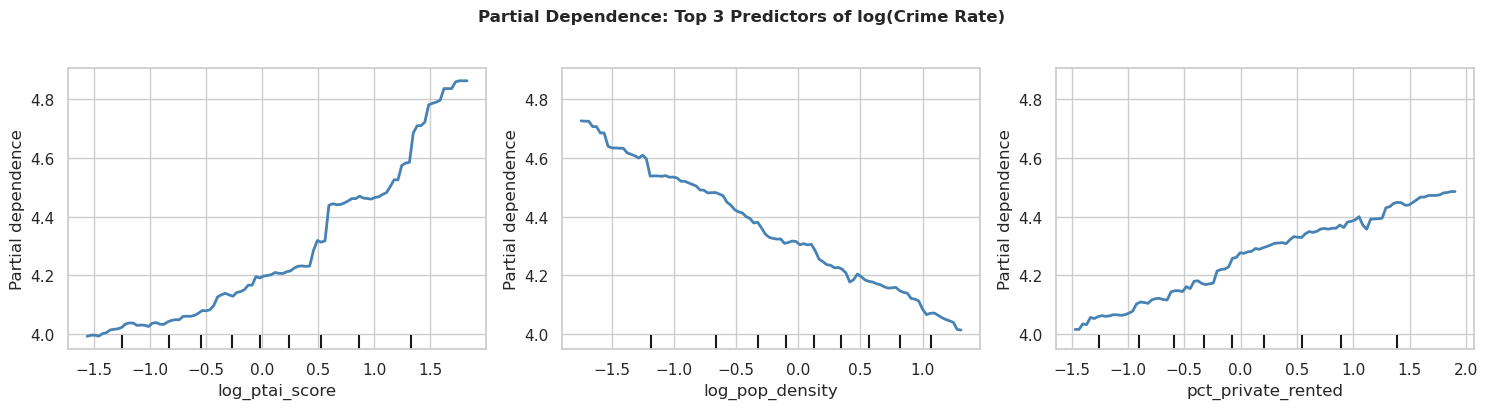

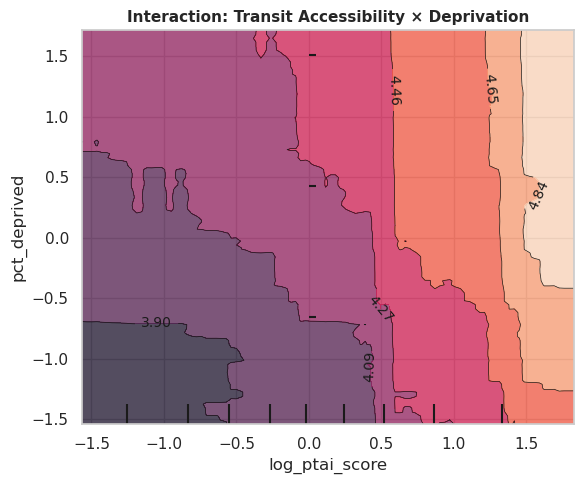

In [25]:
# ============================================================
# CELL 24: Partial Dependence Plots — Top Predictors
# ============================================================

from sklearn.inspection import PartialDependenceDisplay

# Top-3 predictors from permutation importance
top3 = perm_df.head(3)['Feature'].tolist()
print('Top-3 features for PDP:', top3)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(
    best_xgb, X_test_scaled_df,
    features=top3, kind='average', ax=ax,
    line_kw={'color': 'steelblue', 'linewidth': 2}
)
plt.suptitle('Partial Dependence: Top 3 Predictors of log(Crime Rate)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 2D PDP — interaction between PTAL and deprivation
# (tests whether opportunity structure × community structure is super-additive)
fig, ax = plt.subplots(figsize=(6, 5))
PartialDependenceDisplay.from_estimator(
    best_xgb, X_test_scaled_df,
    features=[('log_ptai_score', 'pct_deprived')],
    kind='average', ax=ax
)
plt.title('Interaction: Transit Accessibility × Deprivation',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

High-crime LSOA | actual log_rate = 7.95  predicted = 6.05
Low-crime LSOA  | actual log_rate = 2.20  predicted = 4.62

--- High-crime LSOA: SHAP waterfall ---


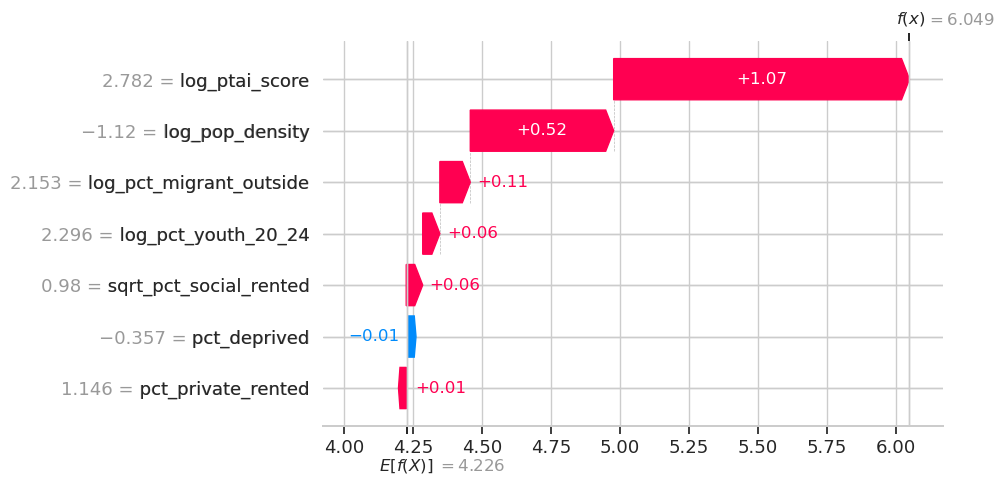


--- Low-crime LSOA: SHAP waterfall ---


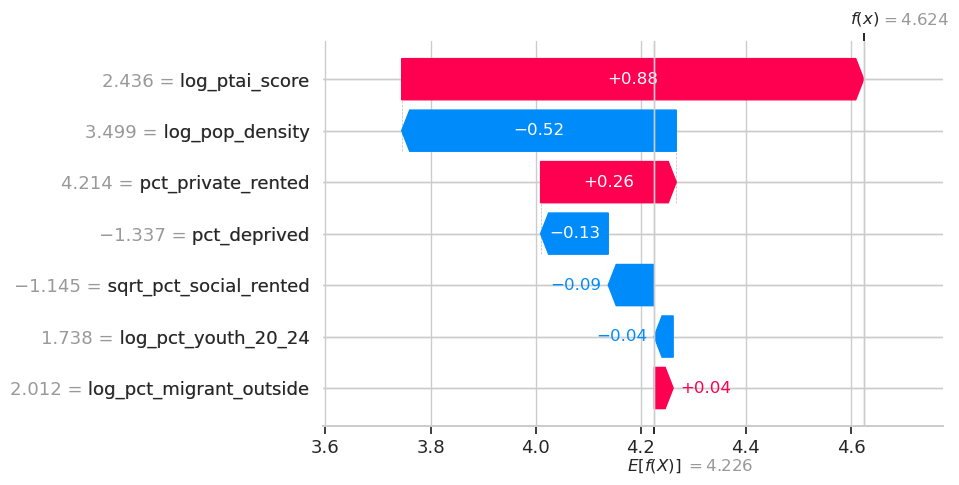

In [26]:
# ============================================================
# CELL 25: SHAP Waterfall — Local Interpretations
# ============================================================

high_idx = int(np.argmax(y_test))   # highest observed log-crime rate
low_idx  = int(np.argmin(y_test))   # lowest observed log-crime rate

print(f'High-crime LSOA | actual log_rate = {y_test[high_idx]:.2f}  '
      f'predicted = {best_xgb.predict(X_test_scaled[[high_idx]])[0]:.2f}')
print(f'Low-crime LSOA  | actual log_rate = {y_test[low_idx]:.2f}  '
      f'predicted = {best_xgb.predict(X_test_scaled[[low_idx]])[0]:.2f}')

print('\n--- High-crime LSOA: SHAP waterfall ---')
shap.plots.waterfall(shap_values_xgb[high_idx], max_display=len(FEATURES_FINAL))

print('\n--- Low-crime LSOA: SHAP waterfall ---')
shap.plots.waterfall(shap_values_xgb[low_idx], max_display=len(FEATURES_FINAL))

In [27]:
# ============================================================
# CELL 26: SHAP vs Permutation Importance — Robustness Check
# ============================================================
from scipy.stats import spearmanr

shap_imp = pd.DataFrame({
    'Feature': FEATURES_FINAL,
    'SHAP_importance': np.abs(shap_values_xgb.values).mean(axis=0)
})

comparison = (perm_df.rename(columns={'Importance': 'PI_importance'})
                      .merge(shap_imp, on='Feature')
                      .sort_values('SHAP_importance', ascending=False)
                      .reset_index(drop=True))
comparison['PI_rank']   = comparison['PI_importance'].rank(ascending=False).astype(int)
comparison['SHAP_rank'] = comparison['SHAP_importance'].rank(ascending=False).astype(int)

print('=== Importance Comparison: Permutation vs SHAP ===')
print(comparison[['Feature', 'PI_importance', 'PI_rank',
                  'SHAP_importance', 'SHAP_rank']].round(4).to_string(index=False))

rho, pval = spearmanr(comparison['PI_rank'], comparison['SHAP_rank'])
consistency = ('highly consistent' if rho > 0.8
               else 'moderately consistent' if rho > 0.5
               else 'inconsistent')
print(f'\nSpearman ρ between PI and SHAP rankings: {rho:.3f}  ({consistency})')

=== Importance Comparison: Permutation vs SHAP ===
                Feature  PI_importance  PI_rank  SHAP_importance  SHAP_rank
         log_ptai_score         0.4856        1           0.1989          1
 sqrt_pct_social_rented         0.1601        4           0.1316          2
        log_pop_density         0.3359        2           0.1276          3
     pct_private_rented         0.1642        3           0.1170          4
           pct_deprived         0.0846        5           0.0873          5
    log_pct_youth_20_24         0.0095        7           0.0231          6
log_pct_migrant_outside         0.0105        6           0.0203          7

Spearman ρ between PI and SHAP rankings: 0.857  (highly consistent)


## RQ2 
SHAP and permutation-based interpretation point to a clear hierarchy of predictors. In the full-sample model, PTAL is the strongest predictor, followed by social-rented housing, population density, private-rented housing, and deprivation. Youth share and recent migration contribute much less once broader neighbourhood structure is taken into account. The small performance gap between Linear Regression and XGBoost suggests that most relationships are broadly stable, although PTAL appears to contain some non-linear structure. These results are consistent with routine activity and crime pattern perspectives, but PTAL should not be interpreted as a simple causal effect of transport accessibility alone. It may partly proxy wider features of centrality, mobility, and urban opportunity structure.

### Robustness Check: Sensitivity to Extreme-Crime LSOAs
Given the pronounced right-skew of raw crime rates (skewness = 13.24) 
and the visible dominance of PTAL in the main model, we conducted a 
sensitivity analysis by re-estimating XGBoost on three trimmed samples 
that excluded the top 0.5%, 1.0%, and 2.0% of LSOAs by raw crime rate. 

After test, the ordering of the main predictors changes very little and PTAL remains the strongest variable. This suggests that the prominence of accessibility is not driven only by a few extreme central cases, although its interpretation should still be treated cautiously.


=== Performance across trim thresholds ===
         Specification  Test R²  Test RMSE
  Full sample (N=4988)    0.558      0.392
Trim top 0.5% (N=4963)    0.541      0.370
Trim top 1.0% (N=4938)    0.541      0.353
Trim top 2.0% (N=4888)    0.527      0.351

=== SHAP importance across trim thresholds ===
                         Full sample  Trim top 0.5%  Trim top 1.0%  Trim top 2.0%
log_ptai_score                 0.199          0.188          0.190          0.161
sqrt_pct_social_rented         0.132          0.134          0.123          0.131
log_pop_density                0.128          0.122          0.114          0.107
pct_private_rented             0.117          0.114          0.105          0.105
pct_deprived                   0.087          0.097          0.091          0.088
log_pct_youth_20_24            0.023          0.022          0.021          0.021
log_pct_migrant_outside        0.020          0.018          0.018          0.019

=== Rank-correlation vs full-sample r

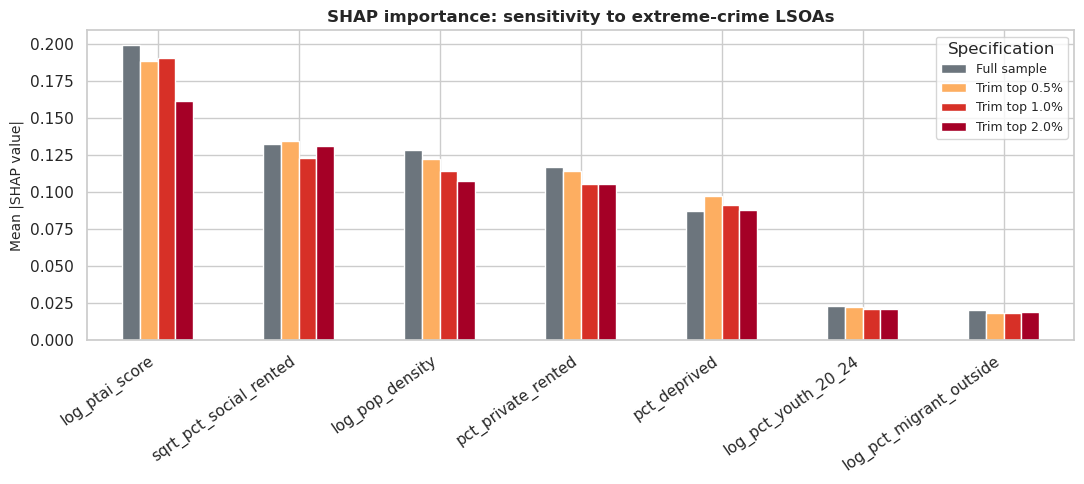

In [28]:
# ============================================================
# CELL 27: Robustness — Extreme-Value Sensitivity Analysis
# ============================================================
# Purpose: Test whether the dominance of PTAL in the main model is
# driven by a small number of extreme-crime LSOAs (e.g., central
# Westminster, King's Cross). We re-fit XGBoost after excluding the
# top 0.5%, 1%, and 2% highest raw crime-rate LSOAs, and compare
# SHAP importance rankings across specifications.
#
# Rationale: The raw Total_Rate_2021 is extremely right-skewed
# (skewness = 13.24). Although log-transformation mitigates this,
# a sensitivity check confirms that key findings are not artefacts
# of a handful of outliers.

from sklearn.base import clone
from scipy.stats import spearmanr

# Work from df_final (already aligned with idx_train/idx_test and FEATURES_FINAL)
# We need the *raw* Total_Rate_2021 to define the trim threshold, so re-attach it
df_sensitivity = df.loc[df_final.index, FEATURES_FINAL + ['log_total_rate_2021',
                                                          'Total_Rate_2021']].copy()

# Reference: baseline SHAP (from main XGBoost model on full data)
baseline_shap = pd.Series(np.abs(shap_values_xgb.values).mean(axis=0),
                          index=FEATURES_FINAL, name='Full sample')

# Store results across trim thresholds
sens_results = {'Full sample': baseline_shap}
perf_results = [{'Specification': 'Full sample (N=4988)',
                 'Test R²': round(xgb_test_r2, 3),
                 'Test RMSE': round(xgb_test_rmse, 3)}]

for trim_pct in [0.5, 1.0, 2.0]:
    # Threshold based on raw crime rate
    threshold = df_sensitivity['Total_Rate_2021'].quantile(1 - trim_pct/100)
    mask = df_sensitivity['Total_Rate_2021'] < threshold

    df_trim = df_sensitivity[mask].copy()
    X_trim  = df_trim[FEATURES_FINAL].values
    y_trim  = df_trim['log_total_rate_2021'].values

    # Fresh train/test split (70/30, same seed for comparability)
    idx_all = np.arange(len(X_trim))
    idx_tr, idx_te = train_test_split(idx_all, test_size=0.3, random_state=42)

    # Standardise using training-set statistics only (avoid leakage)
    scaler_t = StandardScaler()
    X_tr_s = scaler_t.fit_transform(X_trim[idx_tr])
    X_te_s = scaler_t.transform(X_trim[idx_te])
    y_tr   = y_trim[idx_tr]
    y_te   = y_trim[idx_te]

    # Refit XGBoost with the same tuned hyperparameters
    model = clone(best_xgb)
    model.fit(X_tr_s, y_tr)

    test_r2   = r2_score(y_te, model.predict(X_te_s))
    test_rmse = np.sqrt(mean_squared_error(y_te, model.predict(X_te_s)))

    # SHAP on the trimmed test set
    X_te_df = pd.DataFrame(X_te_s, columns=FEATURES_FINAL)
    explainer_t = shap.TreeExplainer(model)
    sv = explainer_t(X_te_df)
    shap_imp_t = pd.Series(np.abs(sv.values).mean(axis=0),
                           index=FEATURES_FINAL,
                           name=f'Trim top {trim_pct}%')
    sens_results[f'Trim top {trim_pct}%'] = shap_imp_t
    perf_results.append({
        'Specification': f'Trim top {trim_pct}% (N={mask.sum()})',
        'Test R²': round(test_r2, 3),
        'Test RMSE': round(test_rmse, 3)
    })

# --- Consolidate: SHAP importance table ---
sens_df = pd.DataFrame(sens_results).round(3)
sens_df = sens_df.sort_values('Full sample', ascending=False)

print('=== Performance across trim thresholds ===')
perf_df = pd.DataFrame(perf_results)
print(perf_df.to_string(index=False))

print('\n=== SHAP importance across trim thresholds ===')
print(sens_df.to_string())

# --- Rank stability: Spearman correlation of ranks ---
print('\n=== Rank-correlation vs full-sample ranking ===')
base_rank = sens_df['Full sample'].rank(ascending=False)
for col in sens_df.columns[1:]:
    r, p = spearmanr(base_rank, sens_df[col].rank(ascending=False))
    print(f'  {col:<18} ρ = {r:+.3f}  (p = {p:.3f})')

# --- Visual: grouped bar chart ---
fig, ax = plt.subplots(figsize=(11, 5))
sens_df.plot(kind='bar', ax=ax,
             color=['#6c757d', '#fdae61', '#d73027', '#a50026'],
             edgecolor='white')
ax.set_ylabel('Mean |SHAP value|', fontsize=10)
ax.set_xlabel('')
ax.set_title('SHAP importance: sensitivity to extreme-crime LSOAs',
             fontsize=12, fontweight='bold')
ax.legend(title='Specification', loc='upper right', fontsize=9)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

### RQ3: Do Socio-Economic Predictors Operate Consistently Across Crime Types?

=== RQ3: Crime-Type Model Comparison ===

--- Total (baseline) ---
  Test R² : 0.558  |  Test RMSE: 0.392

--- Violent ---
  Train R² : 0.780  |  Test R²: 0.560  |  Test RMSE: 0.396
--- Property ---
  Train R² : 0.731  |  Test R²: 0.438  |  Test RMSE: 0.498

=== Performance Summary ===
         Outcome  Test R²  Test RMSE
Total (baseline)    0.558      0.392
         Violent    0.560      0.396
        Property    0.438      0.498

=== SHAP Importance by Crime Type (mean |SHAP value|) ===
                         Total (baseline)  Violent  Property
log_ptai_score                     0.1989   0.1249    0.2285
sqrt_pct_social_rented             0.1316   0.1601    0.0916
log_pop_density                    0.1276   0.1022    0.1418
pct_private_rented                 0.1170   0.1178    0.1326
pct_deprived                       0.0873   0.1436    0.0232
log_pct_youth_20_24                0.0231   0.0309    0.0224
log_pct_migrant_outside            0.0203   0.0165    0.0339


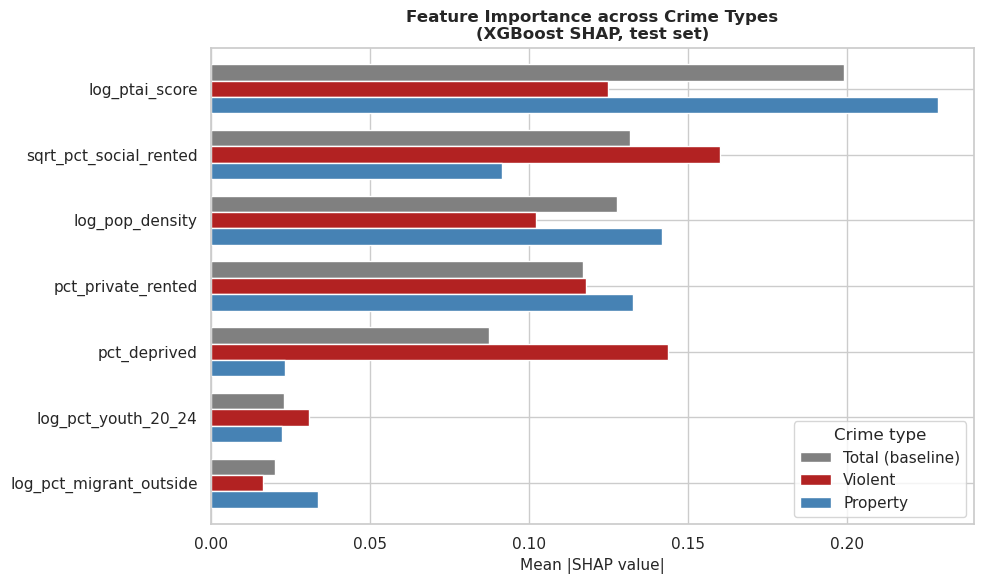

In [29]:
# ============================================================
# CELL 28: RQ3 — Crime-Type Disaggregation (Violent vs Property)
# ============================================================
# Re-fit the XGBoost pipeline on violent and property crime rates
# using the same predictors and hyperparameters. Compare performance
# and SHAP importance to test whether the same socio-economic
# mechanisms drive different crime types.

from sklearn.base import clone

def refit_and_evaluate(y_target, label):
    """Refit XGBoost (with the same tuned hyperparameters) on a new target."""
    y_train_t = y_target[idx_train]
    y_test_t  = y_target[idx_test]

    model = clone(best_xgb)                       # same architecture & hyperparams
    model.fit(X_train_scaled, y_train_t)

    tr_r2   = r2_score(y_train_t, model.predict(X_train_scaled))
    te_r2   = r2_score(y_test_t,  model.predict(X_test_scaled))
    te_rmse = np.sqrt(mean_squared_error(y_test_t, model.predict(X_test_scaled)))

    # SHAP for importance comparison
    expl   = shap.TreeExplainer(model)
    shap_v = expl(X_test_scaled_df)
    shap_imp = pd.Series(
        np.abs(shap_v.values).mean(axis=0),
        index=FEATURES_FINAL, name=label
    )

    print(f'--- {label} ---')
    print(f'  Train R² : {tr_r2:.3f}  |  Test R²: {te_r2:.3f}  |  Test RMSE: {te_rmse:.3f}')
    return {'label': label, 'train_r2': tr_r2, 'test_r2': te_r2,
            'test_rmse': te_rmse, 'shap_importance': shap_imp}

# Prepare targets
y_violent  = df_final_ct['log_violent_rate_2021'].values
y_property = df_final_ct['log_property_rate_2021'].values

# Compare models
print('=== RQ3: Crime-Type Model Comparison ===\n')
res_total    = {'label': 'Total (baseline)', 'test_r2': xgb_test_r2,
                'test_rmse': xgb_test_rmse,
                'shap_importance': pd.Series(
                    np.abs(shap_values_xgb.values).mean(axis=0),
                    index=FEATURES_FINAL, name='Total (baseline)')}
print(f'--- Total (baseline) ---')
print(f'  Test R² : {xgb_test_r2:.3f}  |  Test RMSE: {xgb_test_rmse:.3f}\n')

res_violent  = refit_and_evaluate(y_violent,  'Violent')
res_property = refit_and_evaluate(y_property, 'Property')

# Performance table
perf_table = pd.DataFrame([
    {'Outcome': r['label'], 'Test R²': round(r['test_r2'], 3),
     'Test RMSE': round(r['test_rmse'], 3)}
    for r in [res_total, res_violent, res_property]
])
print('\n=== Performance Summary ===')
print(perf_table.to_string(index=False))

# SHAP importance comparison
shap_compare = pd.concat([res_total['shap_importance'],
                          res_violent['shap_importance'],
                          res_property['shap_importance']], axis=1)
shap_compare = shap_compare.sort_values('Total (baseline)', ascending=False)
print('\n=== SHAP Importance by Crime Type (mean |SHAP value|) ===')
print(shap_compare.round(4))

# Visualisation
fig, ax = plt.subplots(figsize=(10, 6))
shap_compare.plot(kind='barh', ax=ax, width=0.75,
                  color=['grey', 'firebrick', 'steelblue'])
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title('Feature Importance across Crime Types\n'
             '(XGBoost SHAP, test set)', fontsize=12, fontweight='bold')
ax.legend(title='Crime type')
plt.tight_layout()
plt.show()

The crime-type comparison reveals an important difference between violent and property crime. Violent crime is more strongly associated with social-rented housing, deprivation, and PTAL, which is broadly consistent with social disorganisation theory (Shaw & McKay, 1942). Property crime, by contrast, is more strongly associated with PTAL, population density, and private-rented housing, while deprivation plays a much smaller role. This suggests that violent crime is more closely linked to concentrated disadvantage, whereas property crime is more strongly associated with accessible and opportunity-rich urban environments. The two perspectives should therefore be seen as complementary rather than competing explanations.


## Conclusion

[[ go back to the top ]](#Table-of-contents)

This study examined how socio-economic conditions and transport accessibility are associated with crime rates across London LSOAs. Three conclusions emerge. First, neighbourhood-level variables explain a substantial but partial share of crime variation, and the limited advantage of XGBoost over Linear Regression suggests that the overall structure is fairly stable. Second, PTAL is the strongest predictor in the resident-normalised model, alongside housing tenure, density, and deprivation. Third, violent and property crime show different predictor profiles, with the former more closely associated with disadvantage and the latter more closely associated with accessibility and opportunity structure.

Several limitations remain. PTAL is measured using a 2023 file rather than a perfectly matched 2021 accessibility measure, and crime counts are standardised by resident population despite the likely importance of daytime activity in central London. The findings should therefore be interpreted as explaining resident-normalised crime rates rather than a fully activity-adjusted measure of neighbourhood crime exposure. In addition, the analysis does not explicitly model spatial autocorrelation.


## References

[[ go back to the top ]](#Table-of-contents)


- Lightowlers, C., Pina-Sánchez, J., & McLaughlin, F. (2023). Deprivation and crime. *British Society of Criminology Blog*.
- Mandalapu, V., Elluri, L., Vyas, P., & Roy, N. (2023). Crime prediction using machine learning and deep learning: A systematic review. *IEEE Access*, 11, 60153–60170. https://doi.org/10.1109/ACCESS.2023.3286344
- Shaw, C. R., & McKay, H. D. (1942). *Juvenile delinquency and urban areas*. University of Chicago Press.
- Zhang, X., Liu, L., Lan, M., Song, G., Xiao, L., & Chen, J. (2022). Interpretable machine learning models for crime prediction. *Computers, Environment and Urban Systems*, 94, 101789. https://doi.org/10.1016/j.compenvurbsys.2022.101789
- Zhou, Y., Wang, F., & Zhou, S. (2023). The spatial patterns of the crime rate in London and its socio-economic influence factors. *Social Sciences*, 12(6), 340. https://doi.org/10.3390/socsci12060340
- - Brantingham, P. L., & Brantingham, P. J. (1993). Nodes, paths and edges: Considerations on the complexity of crime and the physical environment. *Journal of Environmental Psychology*, 13(1), 3–28. https://doi.org/10.1016/S0272-4944(05)80212-9
- Cohen, L. E., & Felson, M. (1979). Social change and crime rate trends: A routine activity approach. *American Sociological Review*, 44(4), 588–608. https://doi.org/10.2307/2094589
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning: Data Mining, Inference, and Prediction* (2nd ed.). Springer.
- Newton, A. (2014). Crime on public transport. In G. Bruinsma & D. Weisburd (Eds.), *Encyclopedia of Criminology and Criminal Justice* (pp. 709–720). Springer. https://doi.org/10.1007/978-1-4614-5690-2_301